<a href="https://colab.research.google.com/github/sereenajoshy/AI-ML-Intership/blob/main/DAY%2010/DAY_10.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(),lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(),lr=0.0002)

epochs = 20

for epoch in range(epochs):

    for imgs,_ in loader:

        real_imgs = imgs.view(-1,784).to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        # Train D
        outputs = D(real_imgs)
        d_real_loss = criterion(outputs,real_labels)

        z = torch.randn(batch_size,100).to(device)
        fake_imgs = G(z)

        outputs = D(fake_imgs.detach())
        d_fake_loss = criterion(outputs,fake_labels)

        d_loss = d_real_loss + d_fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train G
        outputs = D(fake_imgs)

        g_loss = criterion(outputs,real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] D:{d_loss.item():.4f} G:{g_loss.item():.4f}")

Epoch [1/20] D:0.1137 G:3.1473
Epoch [2/20] D:0.0371 G:5.4770
Epoch [3/20] D:0.1989 G:4.0246
Epoch [4/20] D:0.0538 G:4.5761
Epoch [5/20] D:0.2577 G:4.8071
Epoch [6/20] D:0.2162 G:4.1361
Epoch [7/20] D:0.1359 G:6.1339
Epoch [8/20] D:0.1323 G:3.6138
Epoch [9/20] D:0.5558 G:2.1528
Epoch [10/20] D:0.5055 G:3.1335
Epoch [11/20] D:0.4605 G:3.8599
Epoch [12/20] D:0.1680 G:3.3343
Epoch [13/20] D:0.2176 G:3.9667
Epoch [14/20] D:0.4286 G:2.8693
Epoch [15/20] D:0.4519 G:2.7514
Epoch [16/20] D:0.6855 G:3.7931
Epoch [17/20] D:0.8950 G:5.0336
Epoch [18/20] D:0.5365 G:2.6918
Epoch [19/20] D:0.3113 G:3.1851
Epoch [20/20] D:0.5575 G:2.4530


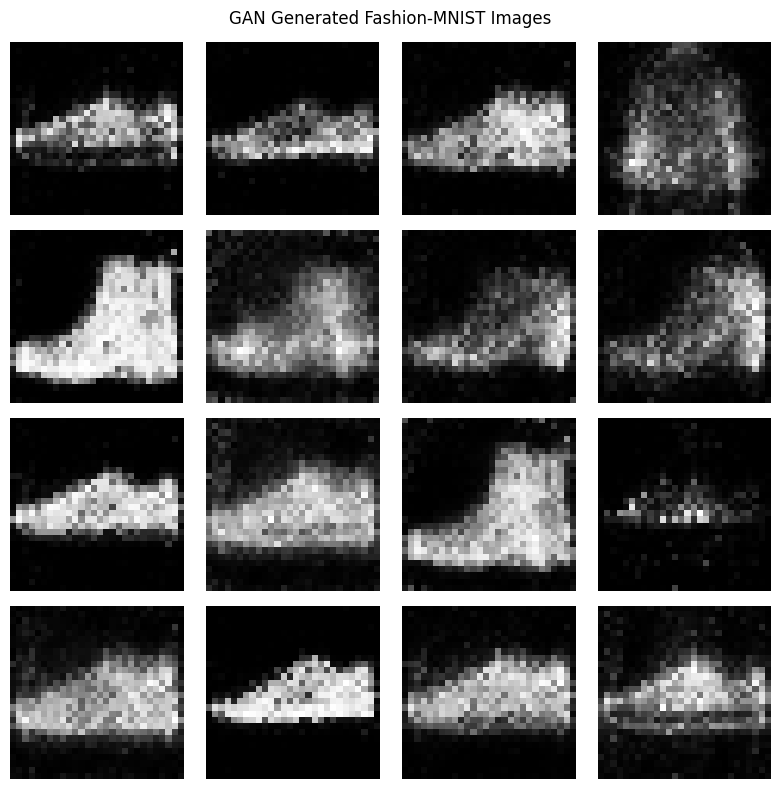

In [ ]:
import matplotlib.pyplot as plt
import torch

G.eval()

with torch.no_grad():
  z=torch.randn(16,100).to(device)
  generated_images=G(z)

generated_images=generated_images.cpu().view(-1,28,28)

fig, axis=plt.subplots(4,4,figsize=(8,8))
for i,ax in enumerate(axis.flatten()):
  ax.imshow(generated_images[i],cmap='gray')
  ax.axis('off')

plt.suptitle("GAN Generated Fashion-MNIST Images")
plt.tight_layout()
plt.show()


In [ ]:
from torchvision.utils import save_image

generated_images=generated_images.unsqueeze(1)
save_image(
    generated_images,
    'generated_images.png',
    nrow=4,
    normalize=True
)

DIFFUSION MODELS

In [1]:
!pip install diffusers transformers accelerate torch torchvision matplotlib tqdm

In [2]:
import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from diffusers import UNet2DModel
from diffusers import DDIMScheduler, DDPMScheduler
from tqdm import tqdm

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Running on:", device)

Running on: cpu


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset Loaded")

Dataset Loaded


In [5]:
model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,

    layers_per_block=1,

    block_out_channels=(32, 64),

    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D"
    ),

    up_block_types=(
        "AttnUpBlock2D",
        "UpBlock2D"
    )
).to(device)

print("Model Created")

Model Created


In [6]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=50
)

In [7]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [8]:
epochs = 3

for epoch in range(epochs):

    progress_bar = tqdm(loader)

    for images, _ in progress_bar:

        images = images.to(device)

        noise = torch.randn_like(images)

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (images.shape[0],),
            device=device
        ).long()

        noisy_images = noise_scheduler.add_noise(
            images,
            noise,
            timesteps
        )

        noise_pred = model(
            noisy_images,
            timesteps
        ).sample

        loss = torch.nn.functional.mse_loss(
            noise_pred,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        progress_bar.set_description(
            f"Epoch {epoch+1} Loss {loss.item():.4f}"
        )

print("Training Complete")

Epoch 3 Loss 0.1232: 100%|██████████| 938/938 [46:57<00:00,  3.00s/it]

Training Complete


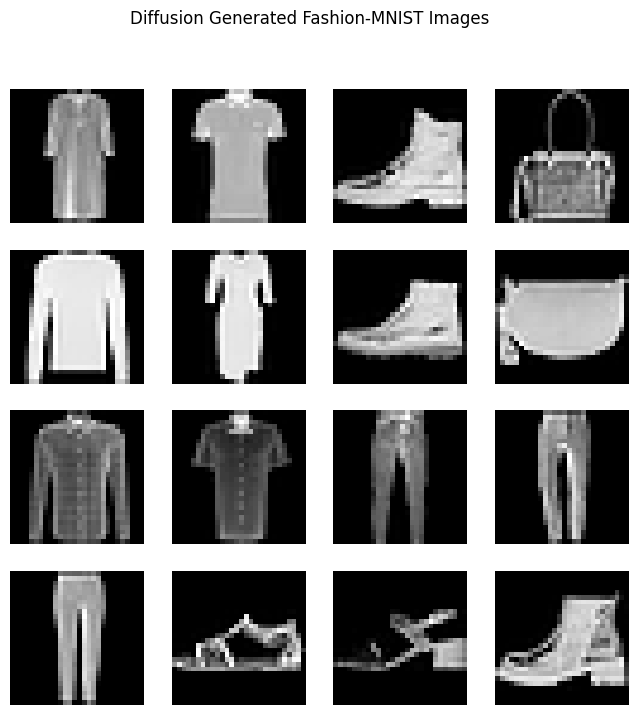

In [9]:
images = images.cpu()

fig, axes = plt.subplots(
    4,
    4,
    figsize=(8,8)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        images[i][0],
        cmap="gray"
    )

    ax.axis("off")

plt.suptitle(
    "Diffusion Generated Fashion-MNIST Images"
)

plt.show()

In [10]:
from torchvision.utils import save_image

save_image(
    images,
    "diffusion_output.png",
    nrow=4,
    normalize=True
)

print("Saved as diffusion_output.png")

Saved as diffusion_output.png
